In [3]:
from typing import List

import torch
import torch.nn as nn

from transformers import AutoModelForCausalLM, AutoTokenizer


# можете сменить на mps на макбуке, но лично у меня он криво работает
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [4]:
import os
os.environ['HF_HOME'] = 'E:\work\models'

# Знакомство с Transformers

## Создание модели и предсказание следующего токена - 5 баллов
Нужно создать модель через `AutoModelForCausalLM`, создать токенайзер через `AutoTokenizer` и получить следующий токен через жадную генерацию!

Для загрузки модели и токенайзера вам помогут функции `.from_pretrained`

**Внимание** на каких-то из функций далее у вас может кончаться видеопамять из-за хранения активаций. Чтобы этого не происходило рекомендуется все вычисления оборачивать в контекстный менеджер `with torch.no_grad()`

In [24]:
model_name = "openai-community/gpt2"
model = AutoModelForCausalLM.from_pretrained(model_name) # Ваш код здесь
tokenizer = AutoTokenizer.from_pretrained(model_name)


text = "This is a sample text"

# Нужно преобразовать text с помощью tokenizer() и подать это в model.forward() (он же просто model())
# после этого мы получим logits [batch_size = 1, seq_len, d_model]
# По этому тензору нужно предсказать следующее слово!

inputs = tokenizer(text, return_tensors="pt")

outputs = model(inputs["input_ids"])
logits = outputs.logits[0, -1, :]
next_token_idx: int = torch.argmax(logits, dim=-1)


next_token = tokenizer.decode([next_token_idx])

assert next_token.strip() == "file"



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

## Используем Generate - 5 баллов

Мы с вами помним про различные виды сэмплинга - top_k, top_p, temperature,frequency penalty.
Отличная новость заключается в том, что нам не нужно все это писать самим! Оно уже включено в [GenerationMixin](https://huggingface.co/docs/transformers/v4.44.2/en/main_classes/text_generation#generation), от которого наследуются модели для генерации текста.

Для генерации есть функция [generate](https://huggingface.co/docs/transformers/v4.44.2/en/main_classes/text_generation#transformers.GenerationMixin.generate)

Ваша задача написать для модели выше генерацию по тексту с:
* Температурой - 0.9
* Top-K - 20
* Repetition Penalty (Frequency Penalty) - 1.2
* максимальное число новых токенов - 10


In [26]:
text = "This is still a sample text, but"
inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    results = []
    for i in range(10):
        gens = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=10,
            temperature=0.9,
            top_k=20,
            repetition_penalty=1.2,
            do_sample=True,
        )
        
        generation: str = tokenizer.decode(gens[0], skip_special_tokens=True)
        results.append(generation)

    assert len(set(results)) > 1, "Все генерации получились одинаковыми, проверьте опции генерации и флаг do_sample!"

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


## Generate Batched - 5
Теперь давайте жадно сгенерируем текст, но забатчуем несколько сэмплов. До этого мы всегда генерировали по батчу размера 1, поэтому у нас не было паддингов!

Когда появляется несколько текстов разной длины, то появляются и паддинги.

Представим себе ситуцию, что у нас батч из двух элементов длины 2 и 5 (токен -1 будет выступать в качестве паддинга **только для удобства визуализации**).

Тогда

```python
input_ids = [
    [3, 2, -1, -1, -1]
    [5, 6,  7,  1,  2]
]
attention_mask = [
    [1, 1, 0, 0, 0],
    [1, 1, 1, 1, 1]
]
```

Представим, что мы сгенерировали еще один токен, тогда

```python
input_ids = [
    [3, 2, -1, -1, -1, 7]
    [5, 6,  7,  1,  2, 8]
]
attention_mask = [
    [1, 1, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1]
]
```

Получается, что у нас паддинги в маске возникают посередине. Мы не будем заниматься реализацией своего алгоритма генерации здесь, но отметим, что добавление паддинга слева значительно упрощает этот процесс.
Тогда исходная последовательность будет:

```python
input_ids = [
    [-1, -1, -1, 3, 2]
    [ 5,  6,  7, 1, 2]
]
attention_mask = [
    [0, 0, 0, 1, 1],
    [1, 1, 1, 1, 1]
]
```

и после генерации следующего токена

```python
input_ids = [
    [-1, -1, -1, 3, 2, 7]
    [ 5,  6,  7, 1, 2, 8]
]
attention_mask = [
    [0, 0, 0, 1, 1, 1],
    [1, 1, 1, 1, 1, 1]
]
```

В качестве задания давайте соберем батч с левым паддингом и проверим, что жадная генерация (10 токенов) совпадает с генерацией на текстах по отдельности!

Для этого нам придется использовать параметр padding_side в конструкторе токенизатора.

In [42]:
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left")
tokenizer.pad_token_id = tokenizer.eos_token_id

In [50]:
texts = ["This is a sample text", "I'm really tired and this is just about"]

tokenized_texts = tokenizer(texts, padding=True, return_tensors="pt")

# Внимание! В данном задании нужна жадная генерация!

# Соберите оба текста в один батч и положите результаты генерации в
# batched_generations
batched_generations: List[str] = []

batch_outputs = model.generate(
    tokenized_texts["input_ids"],
    attention_mask=tokenized_texts["attention_mask"],
    max_new_tokens=10,
    do_sample=False,
)

batched_generations = [
    tokenizer.decode(batch_outputs[0], skip_special_tokens=True),
    tokenizer.decode(batch_outputs[1], skip_special_tokens=True),
]

# Пройдитесь по каждому сэмплу по отдельности и положите результаты генерации
# в single_generations
single_generations: List[str] = []

for text in texts:
    inputs = tokenizer(text, return_tensors="pt")
    gens = model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=10,
        do_sample=False,
    )
    single_generations.append(tokenizer.decode(gens[0], skip_special_tokens=True))

assert len(batched_generations) == 2 and len(single_generations) == 2
for s, b in zip(batched_generations, single_generations):
    assert s == b

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


# Скоринг, Perplexity - 10 баллов

Можно не только генерировать текст. Вспомним, что выдает после lm_head - вектор `[batch_size, seq_len, vocab_size]`, где для каждый вектор `[vocab_size]` это распределение вероятностей по следующему токену!

Опустим размерность batch_size=1 для удобства, seq_len = 4. Пусть у нас есть текст `bos мама мыла раму` (`bos` спецсимвол для начала текста)

Тогда вероятность этого текста расписывается через произведение условных вероятностей:

```
P(bos мама мыла раму) = P(мама | bos) * P(мыла | bos мама) * P(раму| bos мама мыла)
```

Т.е. это вероятность слова при условии его левого контекста.
Зачастую ее обозначают как $P(x_i|x_{<i})$ где $x_i$ - i-е слово, $x_{<i}$ - контекст $[x_1, x_2, x_3, ... x_{i-1}]$
Эти вероятности можно взять из выходного вектора!

Давайте попробуем подсчитать вероятность и perplexity текстов!
perplexity как и вероятность мера того насколько модель "уверена" в тексте, т.е. насколько по оценки ее параметрами данный текст вероятен.

$$Perplexity(X) = exp(-\frac {1} {N} \sum_{i}^{N} log P(x_i | x_{<i}))$$

В этом задании нужно:
1. Посчитать вероятность **text**
2. Посчитать перплексию **text**

Еще одна важная деталь:
работать с вероятностями плохо. Т.к. вероятность представляет собой число от 0 до 1, то при перемножении десятков или даже сотен таких числе теряется точность!
Для этого от произведения вероятностей берут логарифм и получают logprobs - логарифмы вероятностей. Их можно складывать, по свойству логарифма логарифм произведения равен произведению логарифма.

$$ p = p_1 * p_2 * p_3 $$
$$log(p) = log (p_1) + log (p_2) + log (p_3)$$
$$exp(log (p)) = p = exp(log (p_1) + log (p_2) + log (p_3)) = exp (log (p_1 * p_2 * p_3)) = p_1 * p_2 * p_3$$

В pytorch для этого есть `torch.log_softmax`, который считается численно стабильно!

In [66]:
print(f"Beginning of sentence (BOS) token = `{tokenizer.bos_token}`")
print(f"End of sentence (EOS) token  = `{tokenizer.eos_token}`")
text = "<|endoftext|>I'm so very tired of this<|endoftext|>"

inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    
    logits = model(inputs["input_ids"]).logits
    logits = logits[:,:-1,:]
    
    log_probs_all = torch.log_softmax(logits, dim=-1)
    target_ids = inputs["input_ids"][:, 1:]
    
    token_log_probs = log_probs_all.gather(
        dim=-1, 
        index=target_ids.unsqueeze(-1)
    ).squeeze(-1)
    
    total_log_prob = token_log_probs.sum(dim=-1)
    
    N = target_ids.shape[1]  # количество токенов
    perplexity = torch.exp(-total_log_prob / N)
    
    print(logits.shape)
    print(log_probs_all.shape)
    print(target_ids.shape)
    print(token_log_probs.shape)
    print(total_log_prob.shape)
    print(total_log_prob)
    print(perplexity)
    
    ...
    # ваш код здесь!
    # 1. Нужно обрезать logits по длине, т.к. для предсказаний по последнему токену нечего считать
    # 2. Превращаем logits в log_probs
    # 3. Берем вероятности следующих токенов, т.к. по вектору i-й позиции мы предсказываем токен на позиции (i + 1)
    # для этого нам поможет torch.gather
    # 4. Считаем вероятности и perplexity!


# должно получиться что-то около 2.1783e-14 для вероятности и около 51 для ppl

Beginning of sentence (BOS) token = `<|endoftext|>`
End of sentence (EOS) token  = `<|endoftext|>`
torch.Size([1, 8, 50257])
torch.Size([1, 8, 50257])
torch.Size([1, 8])
torch.Size([1, 8])
torch.Size([1])
tensor([-31.4576])
tensor([51.0190])


# Вопросы - 5 баллов

**Ответьте на вопрсоы текстом прямо здесь!**


1. Какое значение P(X) вероятности текста самое "лучшее" в том смысле, что модель максимально уверена в этом тексте и скорее всего его сгенерирует.
2. Какое значение перплексии текста самое "лучшее" в том смысле, что модель максимально уверена в этом тексте и скорее всего его сгенерирует.



1. Самое лучшее значение вероятности текста это единица, потому что вероятность по определению лежит в диапазоне от 0 до 1, и если модель абсолютно уверена в каждом следующем токене и предсказывает их с вероятностью ровно 1, то перемножение всех этих единиц даст единицу. Если же брать сумму логарифмов,то там уже не будет такого ограничения, а лучшим результатом вроде как должен быть 0

2. Самая лучшая перплексия это тоже единица. Перплексия показывает насколько модель удивлена текстом, и если модель идеально предсказывает каждый токен с вероятностью 1, то она вообще не удивляется, и перплексия выходит единица. Но на практике это означало бы что модель всегда выдает один и тот же детерминированный текст без всякого разнообразия, что не очень то и хорошо с точки зрения разнообразия

# Chat-Models

# Формат - 5 баллов
Как мы обсуждали на лекции, все chat-модели принимают входы в своем особом формате.
Он может быть описан текстом, а может быть заложен в шаблон, который доступен через `tokenizer.apply_chat_template`

взял другую,так как на гугл колаб тоже не влезала 8 милиардная моделька

In [ ]:
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

In [ ]:
def move_to_device(d):
    for k, v in d.items():
        d[k] = v.to(device)
    return d

Давайте посмотрим, как chat модель отработает на обычном тексте. Используйте для генерации сэмплинг и kv cache, выведите 5 результатов генерации.

In [ ]:
text = "hello how are you"
inputs = tokenizer(text, return_tensors="pt").to("cuda")

for i in range(5):
    # model.generate...
    generated_text = model.generate(
        inputs["input_ids"],
        do_sample=True
    )
    print(tokenizer.decode(generated_text))
    print("====" * 3)

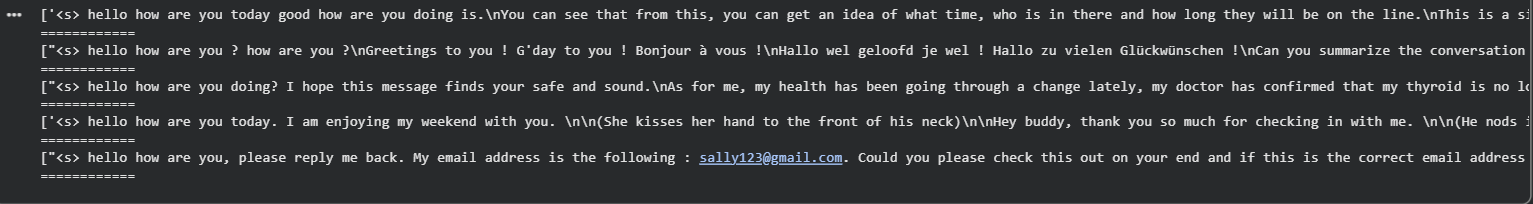

Видим, что текст зачастую выходит мусорный. Это потому что формат входных данных сильно отличается от того, что модель видела на обучении.
Как мы уже обсуждали, у всех chat-моделей свой формат. Где-то он описан просто словами, где-то он заложен в токенайзер. Мы рассмотрим как раз такой случай - за нас есть удобно написанная функция `apply_chat_template`. Давайте используем ее, чтобы получить префикс для генерации модели.

Не забудьте про опцию add_generation_prefix - она добавляет часть формата, после которой ожидается ответ модели!

# Я тут поменял првоерку, так как в "TinyLlama/TinyLlama-1.1B-Chat-v1.0" по-другому устроен шаблон

In [ ]:
messages = [
    {"role": "user", "content": "hello"},
    {"role": "assistant", "content": "I'm good. How can I help you today"},
    {"role": "user", "content": "I love you"},
]

prefix = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    continue_final_message=False)

reference = """<|user|>
hello</s>
<|assistant|>
I'm good. How can I help you today</s>
<|user|>
I love you</s>
<|assistant|>"""

assert prefix.strip() == reference.strip()

Давайте посмотрим, что нам ответит модель!

In [ ]:
inputs = tokenizer(prefix, return_tensors="pt").to("cuda")
generated_text = model.generate(
    inputs["input_ids"],
    do_sample=True
)
print(tokenizer.decode(generated_text))

[" <|user|>\nhello</s> \n<|assistant|>\nI'm good. How can I help you today</s> \n<|user|>\nI love you</s> \n<|assistant|>\nOf course! Words from the heart can mean a lot to someone special to you. Here's what I can do for you:\n\n1. Write a note and leave it on your pillow or nightstand.\n2. Write a message on your phone or laptop (if you don't feel comfortable writing in front of someone).\n3. Create a scrapbook or album for special moments with your loved one.\n4. Make a video message expressing your love and appreciation.\n5. Send a handwritten card or letter expressing your gratitude and desire to communicate with your partner.\n6. Hold a video call or send a video message to your partner.\n7. Make a wish or request for your partner's happiness or well-being.\n8. Send a virtual gift or treat (like a favorite food, music, or movie) to your partner.\n9. Spend special time together, like having a romantic dinner or a picnic.\n10. Bring little love notes or trinkets to your partner's home/workplace or leave them as a gesture with a card or note.\n\nremember, love truly knows no bounds and being heartfelt to your significant other can go a long way in expressing your love and commitment. I recommend you take your time, be creative, and enjoy the process - it's the thought that matters most!</s>"]


## Benchmark - 15

Перед нами датасет MMLU - датасет вопросов и ответов в стиле multiple choice.
* question - вопрос
* choices - варианты ответа
* answer - номер правильного ответа

In [ ]:
from datasets import load_dataset
mmlu = load_dataset("cais/mmlu", "global_facts", split="test")
mmlu[1]

{'question': 'What was GDP per capita in the United States in 1850 when adjusting for inflation and PPP in 2011 prices?',
 'subject': 'global_facts',
 'choices': ['About $300', 'About $3k', 'About $8k', 'About $15k'],
 'answer': 1}

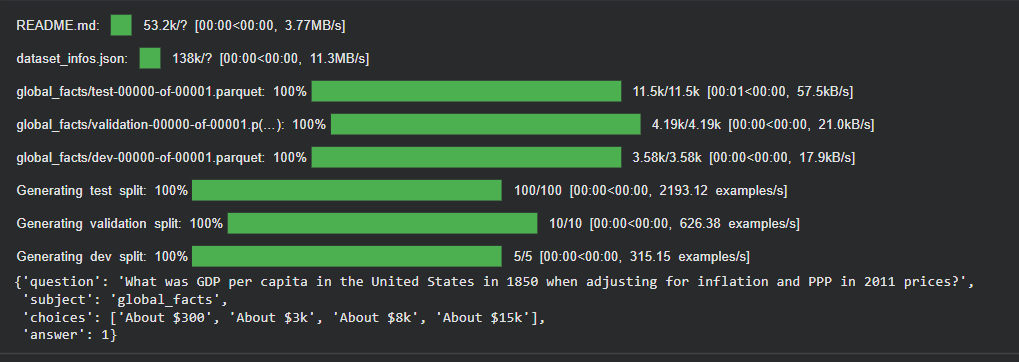

Наша задача здесь решить задачу многоклассовой классификации.
Для этого нужно посчитать
$$P(choices_i | question)$$
т.е. для посчитать вероятность каждого варианта ответа для вопроса. Мы это уже делали кодом выше!

После этого давайте брать самый вероятный ответ и считать, что модель его выбрала.
После этого давайте посчитаем accurracy, т.е. долю правильных ответов.
Вместо вероятностей для подсчета лучше использовать logprobs.

Итого, что нужно сделать:
1. Пройтись по датасету, для каждого question и каждого из соответствующих choices получить самый вероятный ответ.
2. Посчитать итоговый accuracy

**Важно**
1. Выше мы уже написали скоринг текста с помощью LLM, для этого задания можно адаптировать функцию.
2. Если делаете варианты с батчеванием помните: длины choices могут быть разными! Нужно не считать вероятности по паддингам. В этом нам помогут attention_masks из выходов `tokenizer()`
3. В данном задании для простоты мы игнорируем формат ответа llama3 и делаем скоринг по f"{question} {answer}"


Попробуйте для начала написать вариант со скорингом для батча размера 1, а потом для батча размера 3 или 5. Код должен корректно работать для батча любого размера и выдавать одинаковую итоговую точность.

За задание, в котором код работает только с батчом размера 1, 2, 4 можно получить **только 10 баллов**

In [ ]:
def sample_to_texts(sample):
    return [sample["question"] + " " + answer for answer in sample["choices"]]

all_samples_formatted = sum([sample_to_texts(sample) for sample in mmlu], [])
print(*all_samples_formatted[2:6], sep="\n")

def predict_choice_batched(model, tokenizer, texts):
    inputs = tokenizer(texts, padding=True, return_tensors="pt").to(device)
    
    with torch.no_grad():
        logits = model(inputs["input_ids"]).logits  # [4, seq_len, vocab]
        
        # Обрезаем и считаем log_probs для каждого токена
        logits = logits[:, :-1, :]
        log_probs = torch.log_softmax(logits, dim=-1)
        
        target_ids = inputs["input_ids"][:, 1:]
        
        # Учитываем attention_mask, чтобы не считать паддинги
        mask = inputs["attention_mask"][:, 1:]  # маска для target позиций
        
        token_log_probs = log_probs.gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1)
        
        # Суммируем, но только где mask == 1
        total_log_probs = (token_log_probs * mask).sum(dim=-1)
    
    best_idx = torch.argmax(total_log_probs).item()
    return best_idx

all_predict = []
correct = 0
total = 0
mmlu_question_idx = 0
for i in range(0, len(all_samples_formatted), 4):
  best_idx = predict_choice_batched(model, tokenizer, all_samples_formatted[i:i+4])

  total += 1
  if mmlu[mmlu_question_idx]["answer"] == best_idx:
    correct += 1

  all_predict.append(best_idx)

accuracy = correct / total

print(f"Accuracy: {accuracy}")

As of 2016, about what percentage of adults aged 18 years or older were overweight? 40%
As of 2016, about what percentage of adults aged 18 years or older were overweight? 80%
What was GDP per capita in the United States in 1850 when adjusting for inflation and PPP in 2011 prices? About $300
What was GDP per capita in the United States in 1850 when adjusting for inflation and PPP in 2011 prices? About $3k


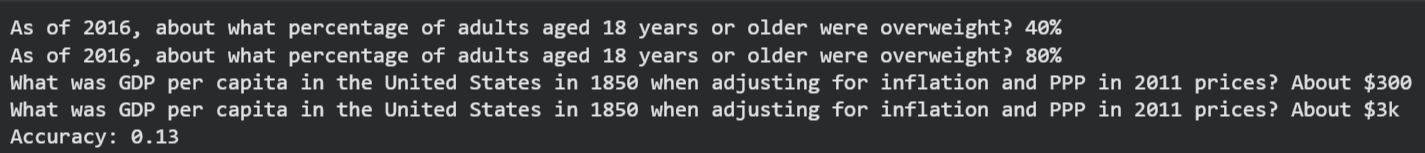

# Вопросы - 5 баллов

**Ответьте на следующие вопросы (5 баллов в сумме)**:
1. Как влияет длина ответа на вероятность ответа при скоринге? Если есть какие-либо проблемы, как бы вы с этим боролись.
2. Если к началу каждого ответа добавилить метки A) B) C) D) станет ли модель отвечать лучше или хуже?
Стоит ли по-вашему добавлять эти метки?


1. Чем длиннее ответ, тем больше токенов перемножается в вероятности. Даже если модель уверена в каждом токене, произведение большего количества вероятностей (каждая < 1) даёт меньшую итоговую вероятность. В итоге более короткие ответы получают систематическое преимущество перед длинными, даже если они менее правильные по сути.
Как бороться:

Нормировать по длине — использовать среднюю логарифмическую вероятность (то есть total_log_prob / N), а не сумму. Это уже встроено в perplexity.

Или использовать длину ответа в качестве коэффициента при сравнении.


2. Станет лучше
Потому что:

Модель во время обучения видела множество примеров multiple choice с метками A, B, C, D.

Метки помогают модели структурировать варианты и понимать, что это выбор, а не просто генерация продолжения.

Без меток модель может воспринимать каждый вариант как независимый текст и не сравнивать их явно.